# Blackjack EV Analysis under Deck Depletion

## Introduction

Blackjack is a stochastic decision-making problem in which optimal play depends on both the player’s hand and the composition of the remaining deck. The basic strategy for blackjack implies that the deck is infinite and, hence, the probabilities of drawing a certain card stay constant. Nevertheless, in real games these probabilities are significantly influenced by card depletion in the remaining deck, which creates opportunities for strategies like card counting.

This study analyses how changes in deck composition influence the expected value (EV) of net profit when the player chooses one of the  available actions (hit, stand, double, split) in specific decision states.

We focus on controlled case studies (e.g., 16 vs 10, A,7 vs 9, 8,8 vs 6), where the player hand and dealer upcard are fixed, while the deck composition is systematically varied. In particular, we analyze the effect of:
- ten-card density (high cards),
- ace density.

Expected values are estimated using a Monte Carlo simulation with adaptive stopping based on standard error thresholds. The analysis was completed for a game with only one deck to simulate card depletion. For each state, we compute:
- EV for all legal actions,
- the optimal action (max EV),
- the gap between the best and second-best actions (decision confidence).

## Goals

The main objectives of this analysis are:
- to establish how deck composition affects optimal decision-making,
- to identify situations where optimal play deviates from basic strategy,
- to study the effect of card depletion on decision-making.

## Structure of the Analysis

For each selected case:
- we visualize the difference between competing actions (e.g., EV(hit) − EV(stand)),
- identify regions where the optimal action changes,
- compare optimal decisions to fixed (basic) strategy,
- and assess the confidence of decisions via EV gaps.

This approach allows us to isolate and understand the impact of deck composition on individual decision points in blackjack.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({"font.size": 12})
plt.style.use("ggplot")

In [2]:
import os

folder = "datasets/cases"
files = os.listdir(folder)

datasets = {}

for f in files:
    if f.endswith(".csv"):
        name = f.replace(".csv", "")
        datasets[name] = pd.read_csv(os.path.join(folder, f))

In [3]:
from plotting import plot_hit_vs_double, plot_hit_vs_stand, plot_hit_vs_stand_soft, plot_split

### Case: 16 vs 10
This is one of the typical borderline situations in blackjack.

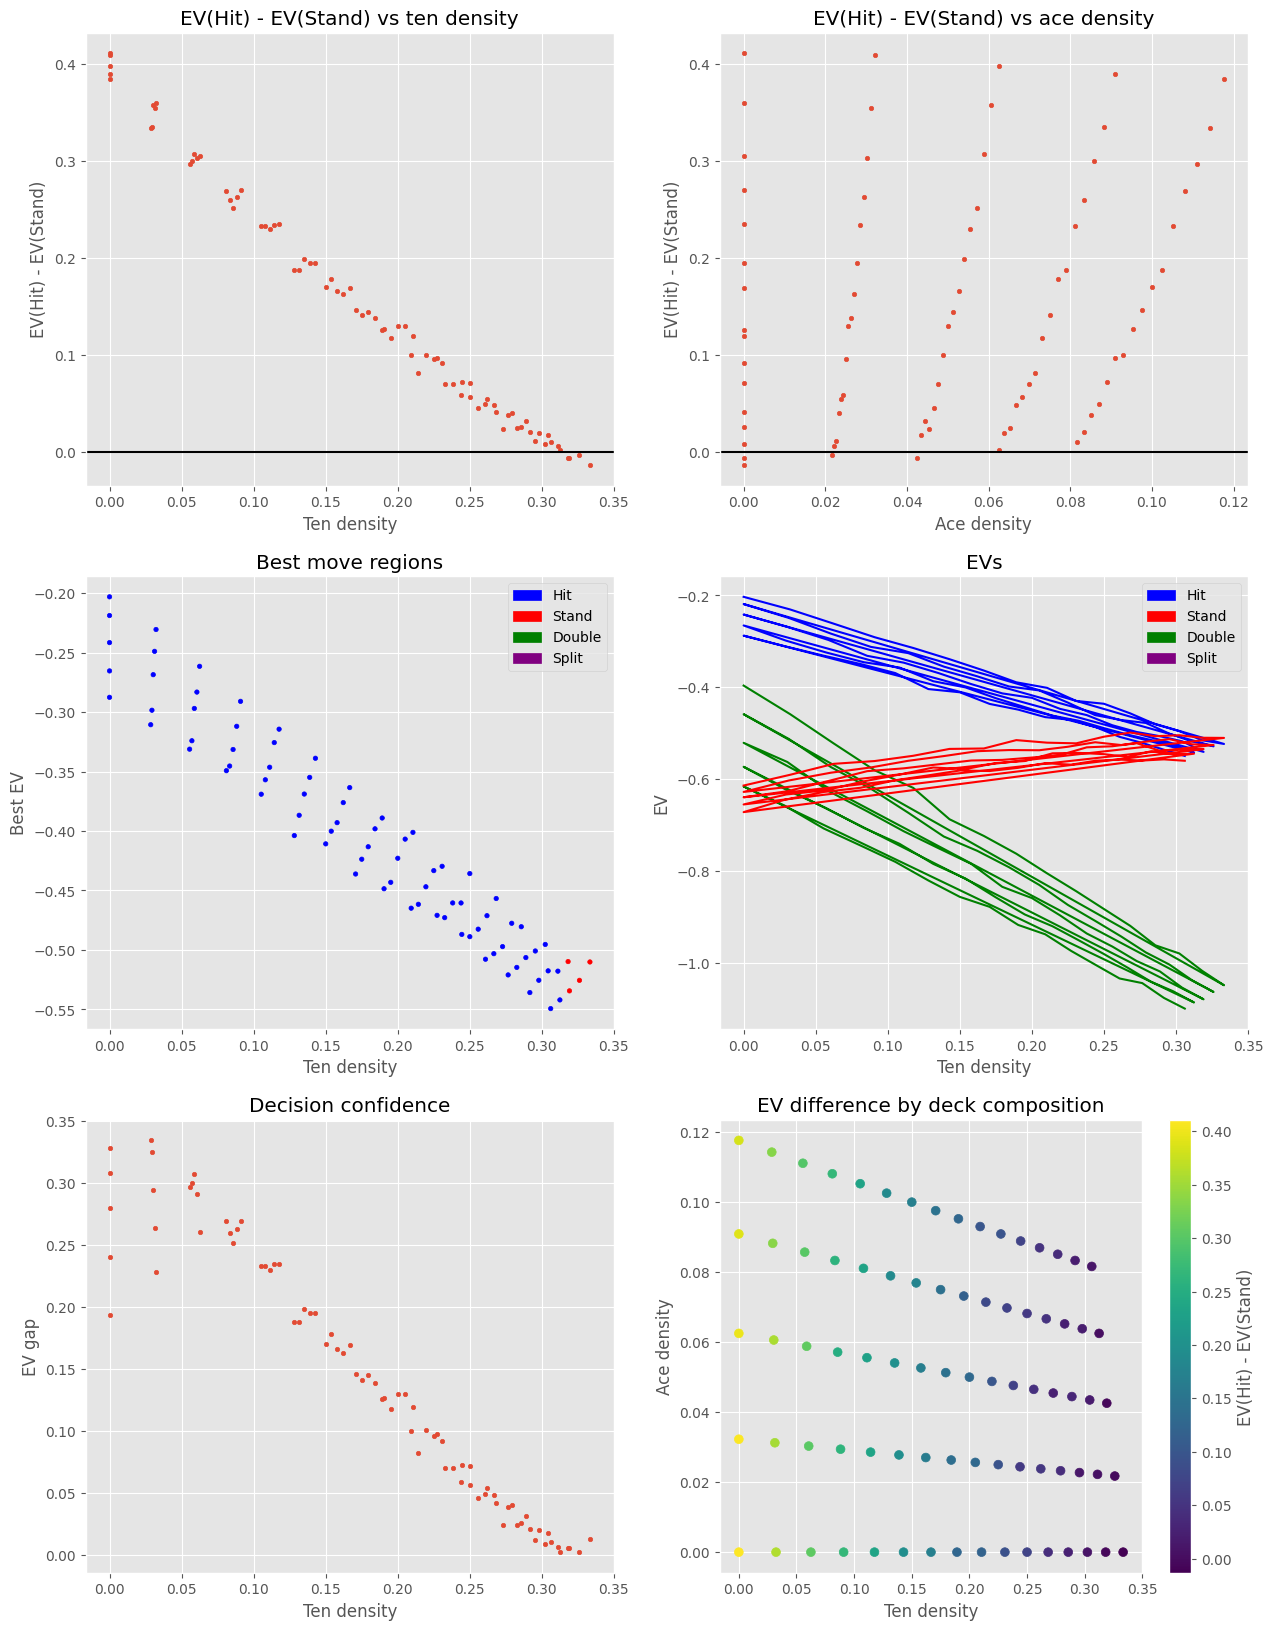

In [4]:
plot_hit_vs_stand(datasets, "case_16vs10")

### Analysis
As can be seen from the second plot, the decision-making in this particular case is virtually independent on the density of aces. The density of tens, however, is detrimental for choosing the best move. With high ten density the EV of hit decreases, which can easily be explained by the risks of a bust when drawing a 10.
In a perfect game with $N_d$ being the number of decks used:
$$
\lim_{N_d \to \infty} Pr({10}) = 16/52 ≈ 0.31,
$$
which is exactly the borderline for decision-making, as is visualised in Decision confidence plot. In this particular case the fixed strategy is perfectly in line with the best move according to expected values, unless the cards of low ranks (in this case 2-5) are depleted, in which case the risks of busting outweigh the possibility of dealer drawing more than the player.
Nevertheless, it is essential to point out that the EV(best move) is still negative and in a perfect game constitute app. -0.5 which means that the dealer wins 3 times more often than the player with a perfect strategy
***
## Case: 13 vs 2
This case represents another borderline choice with high influence of card depletion.

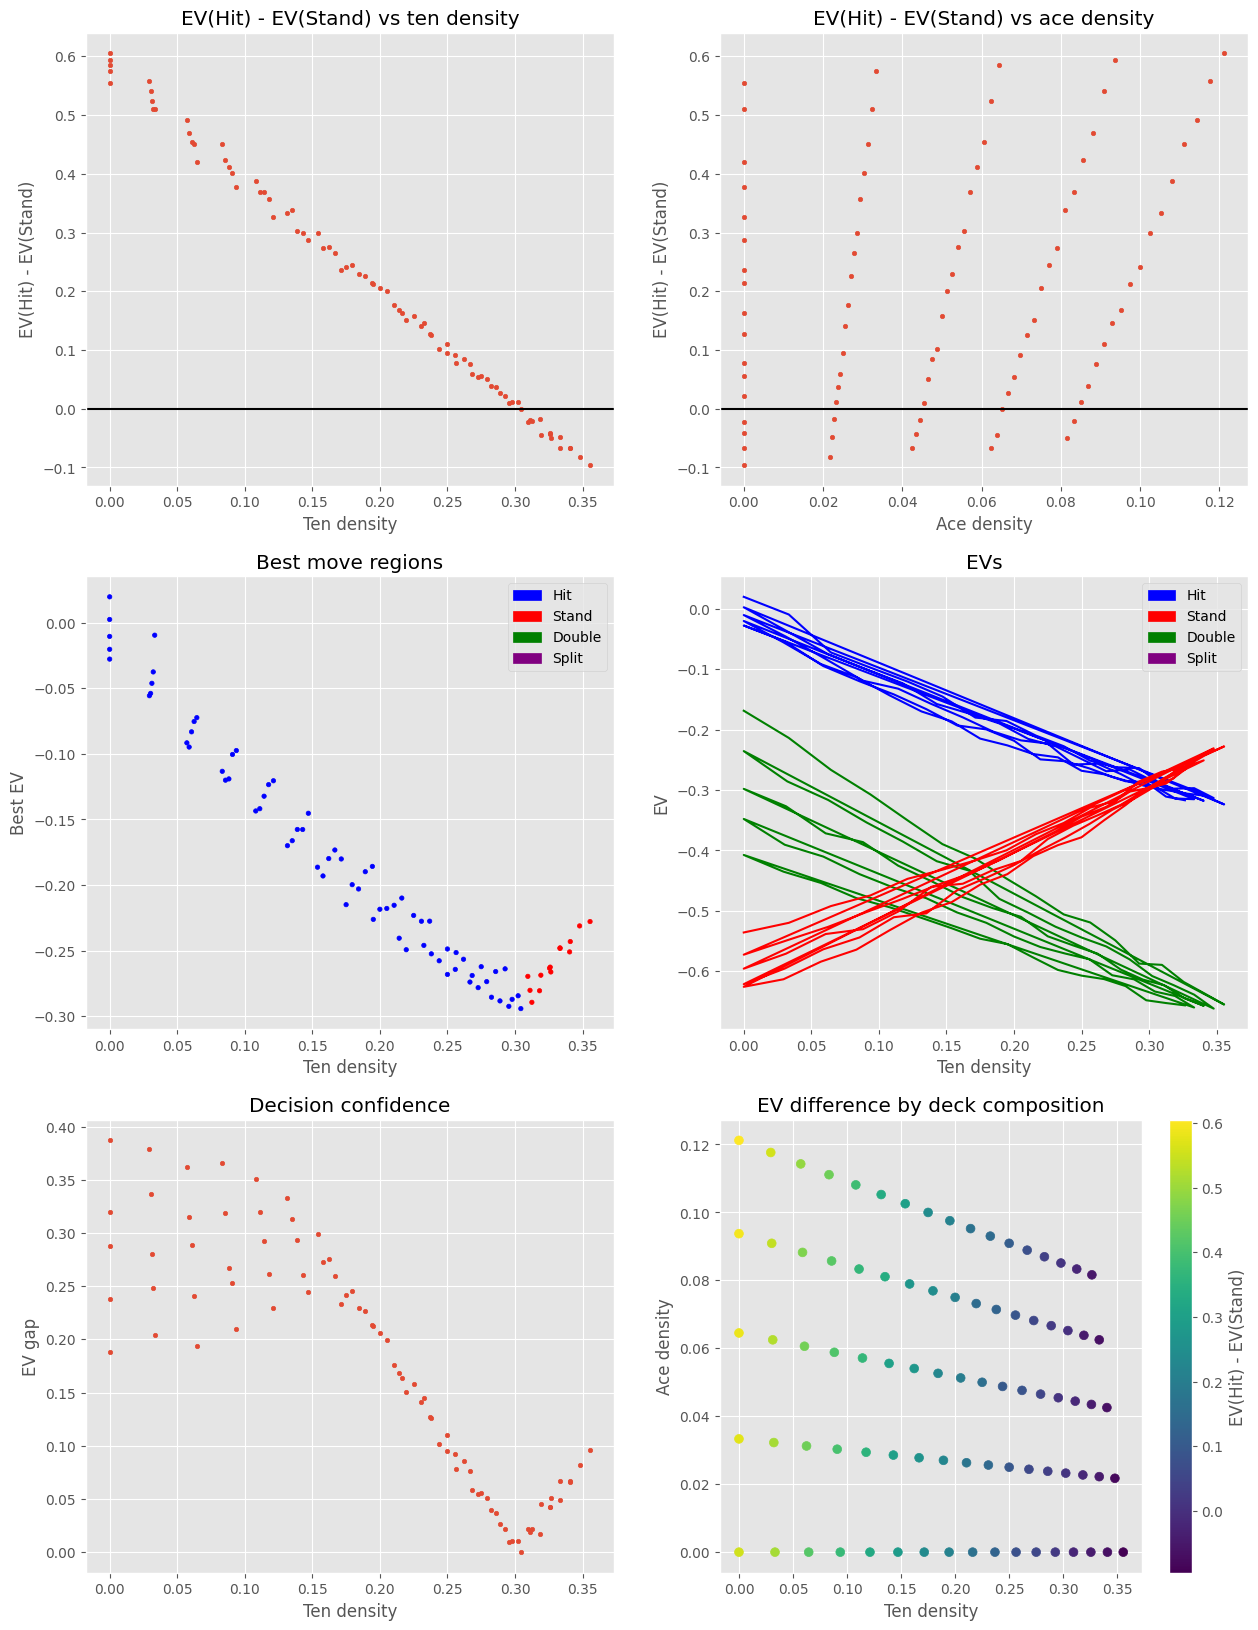

In [5]:
plot_hit_vs_stand(datasets, "case_13vs2")

### Analysis
This case is extremely similar to the previous one. The only minor difference is that it spans more values in the ten density, $D_T ∈ [0, 0.36]$. The boundry is, again, achieved in a perfect game with $N_d \to \infty$, with EV(Hit) outweighing EV(Stand) in games with depleted tens. Another difference is that the absolute value of EV(best move) is higher. This is understandable since $13 < 16$ and the risks of busting diminish the less the total of the player's hand is.
***
## Case: 12 vs 3
Again, another borderline case worth analysing.

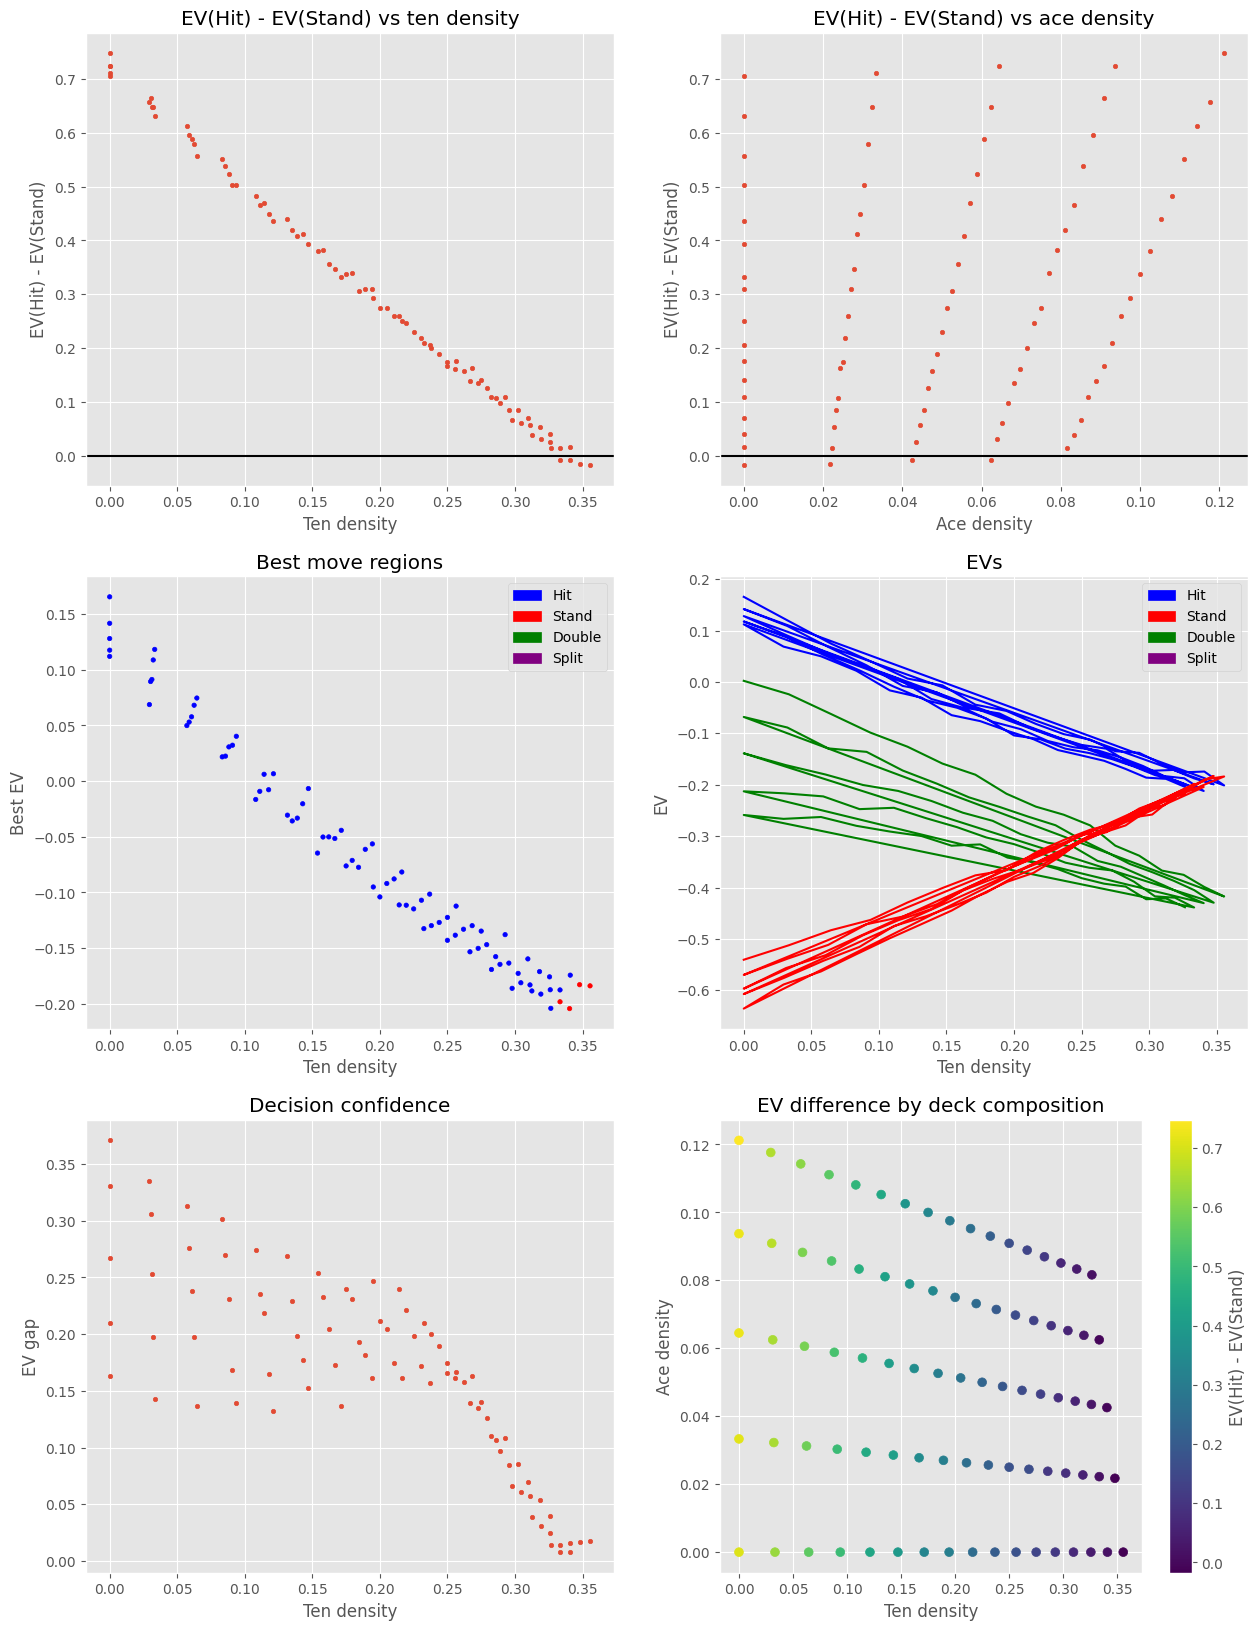

In [6]:
plot_hit_vs_stand(datasets, "case_12vs3")

### Analysis
This case is slightly different to the previous ones. Unlike the first two cases, in this situation the EV(Hit) is actually positive for $D_T < 0.10$. The decision border is also slightly shifted towards $D_T ≈ 0.33$, which constitutes a deck saturated with cards of rank 10. Nevertheless, in most cases with ten depletion hitting still remains the optimal move.
***
## Case: 11 vs 6
This case is typical for analysing EV of net profit after doubling your bet.

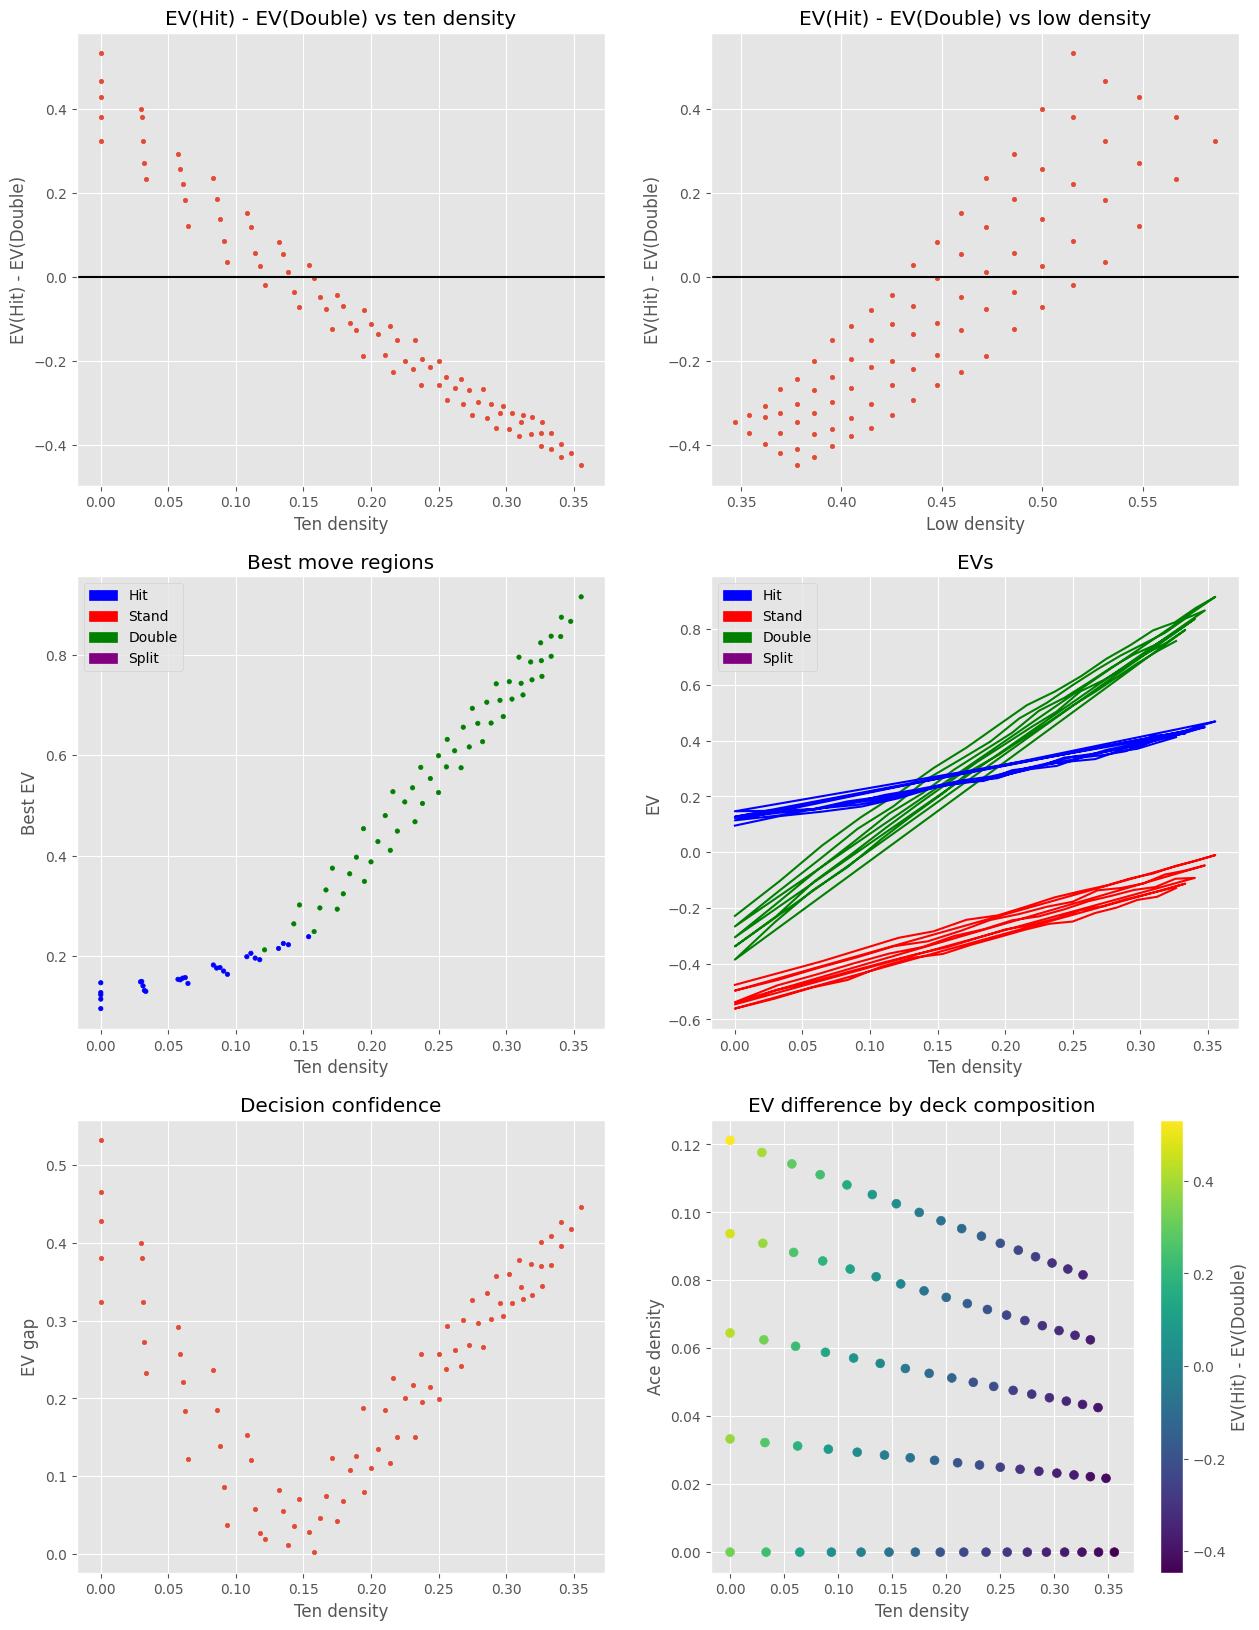

In [7]:
plot_hit_vs_double(datasets, "case_11vs6")

### Analysis
This case is significantly different. With high saturation of tens in the remaining deck it is obvious that doubling the bet is the best option. The border between hit and double lies in $D_T ∈ [0.14, 0.17]$, which is illustrated in the EVs graph. This decision is, again, not influenced by the density of aces. Another notion is that in all these graphs the EV of a certain move has what seems to be a linear dependence on the ten density, which can be explained by the fact that the probability of e.g. getting 21 after a doubled 11 is the same as $Pr({10})$, which is basically the ten density.

## Case: Soft 18 vs 9

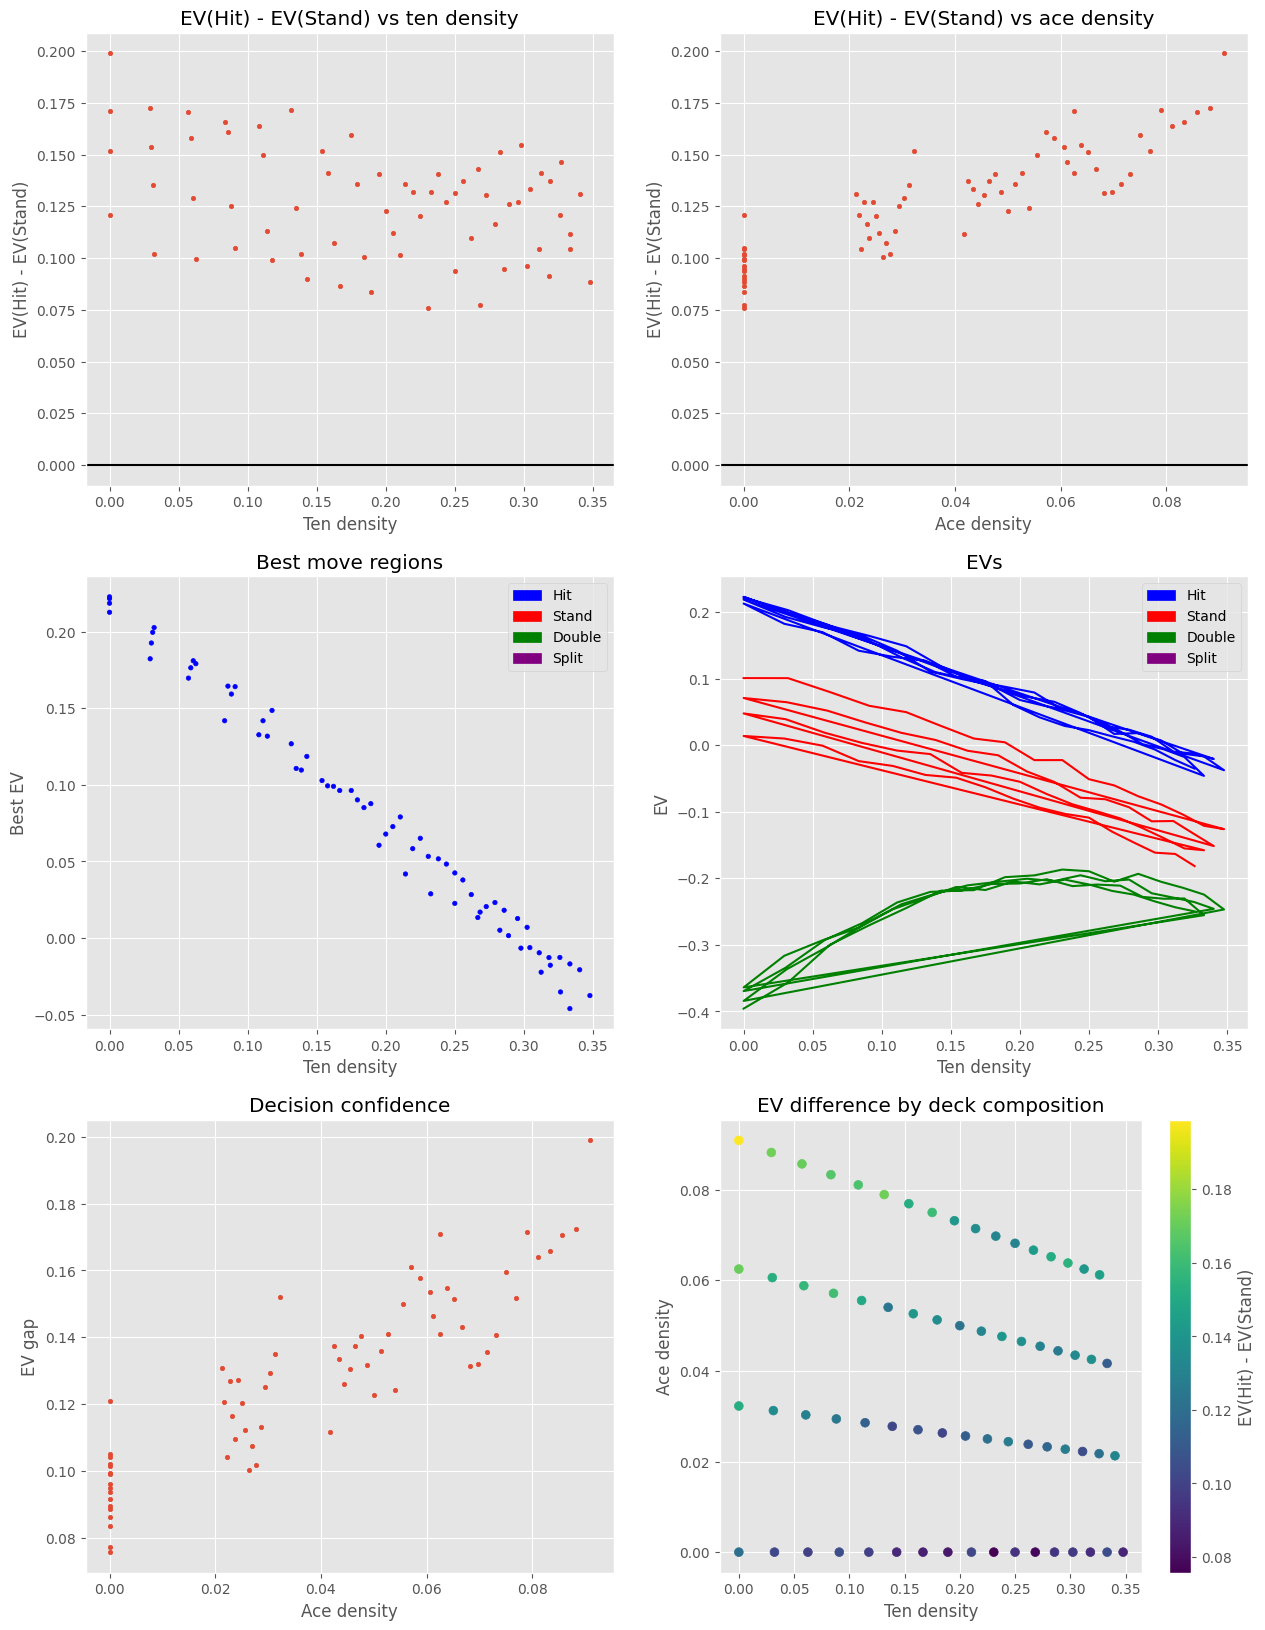

In [8]:
plot_hit_vs_stand_soft(datasets, "case_soft18vs9")

### Analysis
In this case neither the ten nor the ace density affects the decision-making. The hitting remains the dominant strategy independent of the probabilities. Against the dealer's 9 the total of 18 is often not enough to secure the win and, thus, hitting becomes more optimal than standing. Nonetheless, we can see a downward trajectory in the EV(ten density), which is reasonable considering the fact that an increase in the $Pr({10})$ leads to an increase in risk of busting in cases of subsequent hitting and losing. The aces in this particular scenario play virtually the same role as the low-rank cards. In case of drawing an ace it will inadvertently be counted as a 1 and not as 11. All in all, the only way to get higher total than 18 with only one additional card, the player must draw 2 or 3, the possibility of which is way too low. The actual reason why hitting still prevails is that it opens possibilities of subsequent hitting when the hand stops being soft (i.e. the Ace is no longer counted as 11). The subsequent total $T ∈ \{13, ..., 21\}$.
***
## Case: Soft 17 vs 2

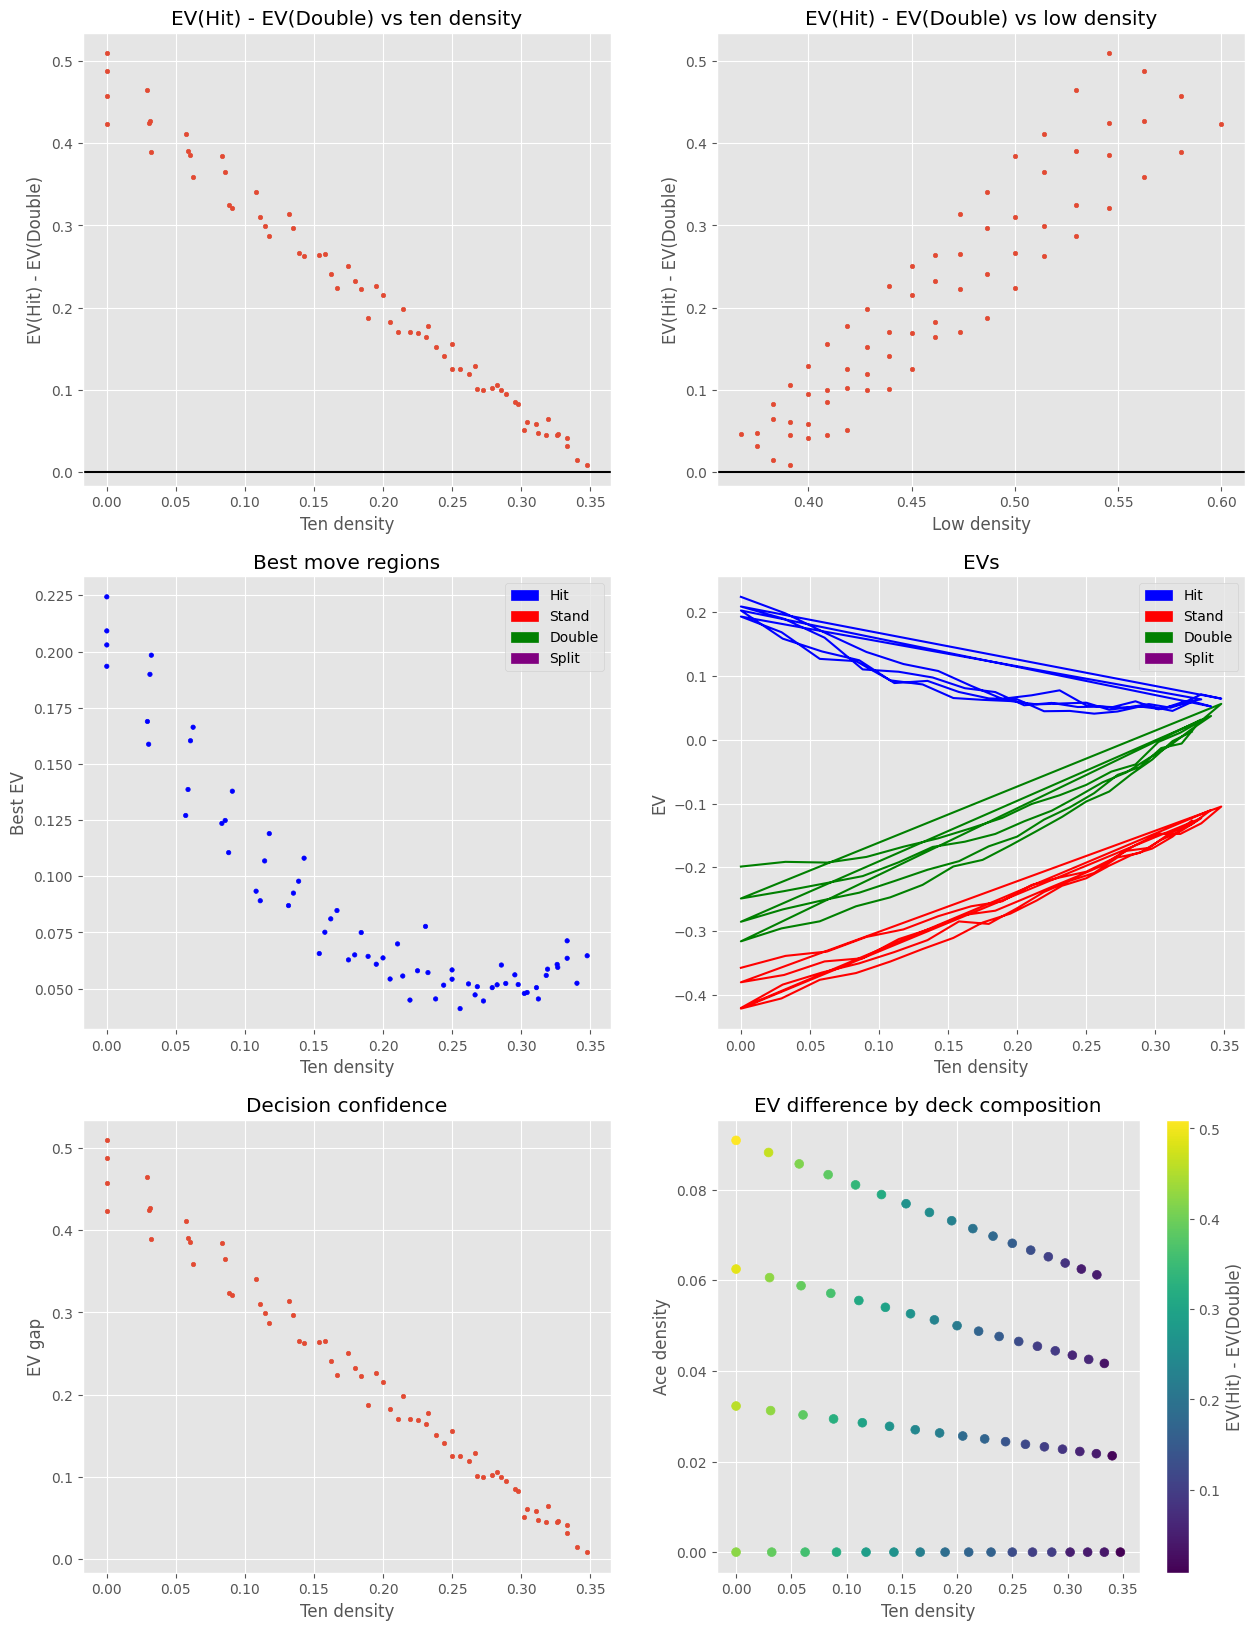

In [9]:
plot_hit_vs_double(datasets, "case_soft17vs2")

### Analysis
This case is similar to the previous one with respect to the optimal strategy. The dealer's two is ambiguous, it implies that the dealer will always have to draw at least one additional card, which makes it difficult to predict the dealer's total. However, hitting after getting a soft 17 is still the dominant strategy, especially in games with low ten density. We can also observe the upward trend in EV(Double) vs ten density, which constitutes that the total of hard 17 is still more likely to win.
***
## Case: 8,8 vs 6
This is a typical case for splitting hands.

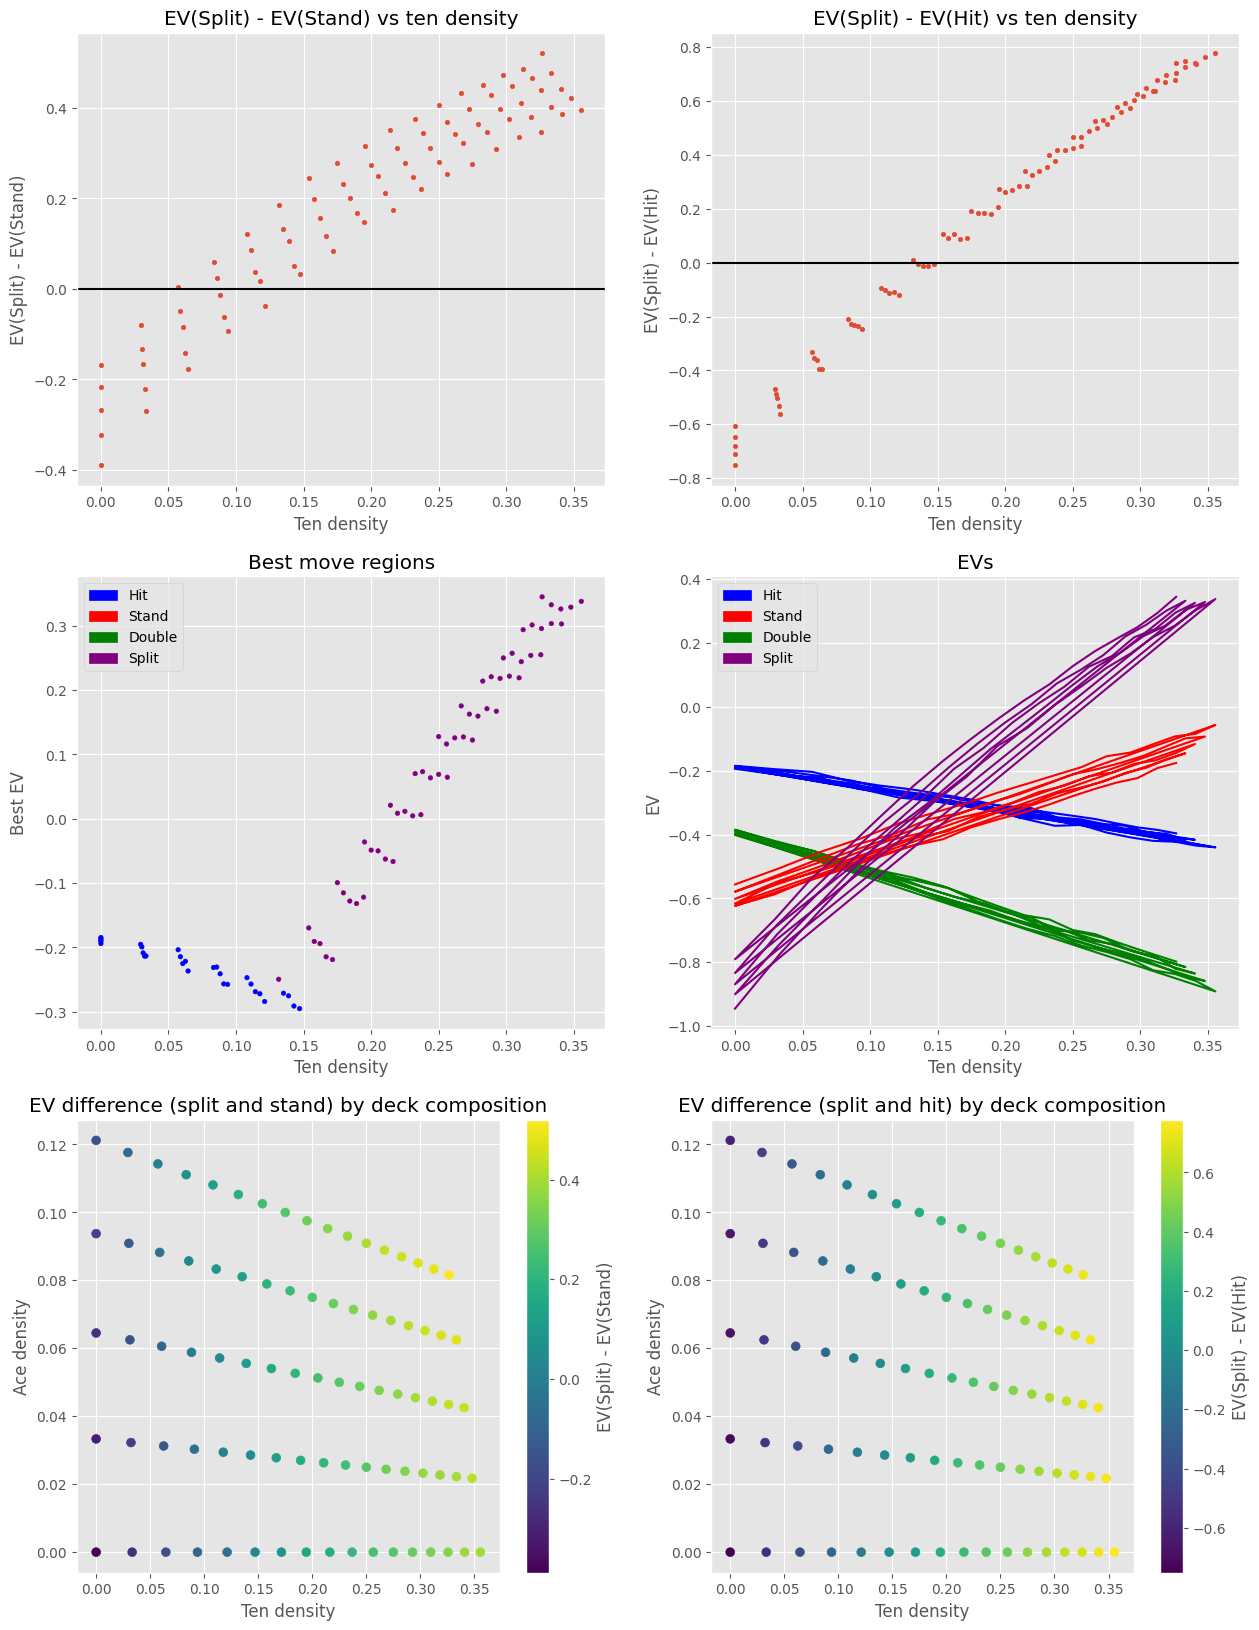

In [10]:
plot_split(datasets, "case_8-8vs6")

### Analysis
This case is so far unique since it takes the possibility of splitting into account. While, at a first glance, it may seem that splitting 8s should always be the dominant strategy in canonical blackjack, it is not the case with depleted tens in the deck. The decision borderline lies in $D_T ∈ [0.12, 0.15]$ with hitting being the best strategy below the $D_T$ threshold, which can be derived from the Best move regions graph. Below a certain point even standing outperforms splitting. However, in a perfect game with $D_T \to \frac{4}{13}$ splitting remains the right choice.
***
## Case: 8,8 vs 10

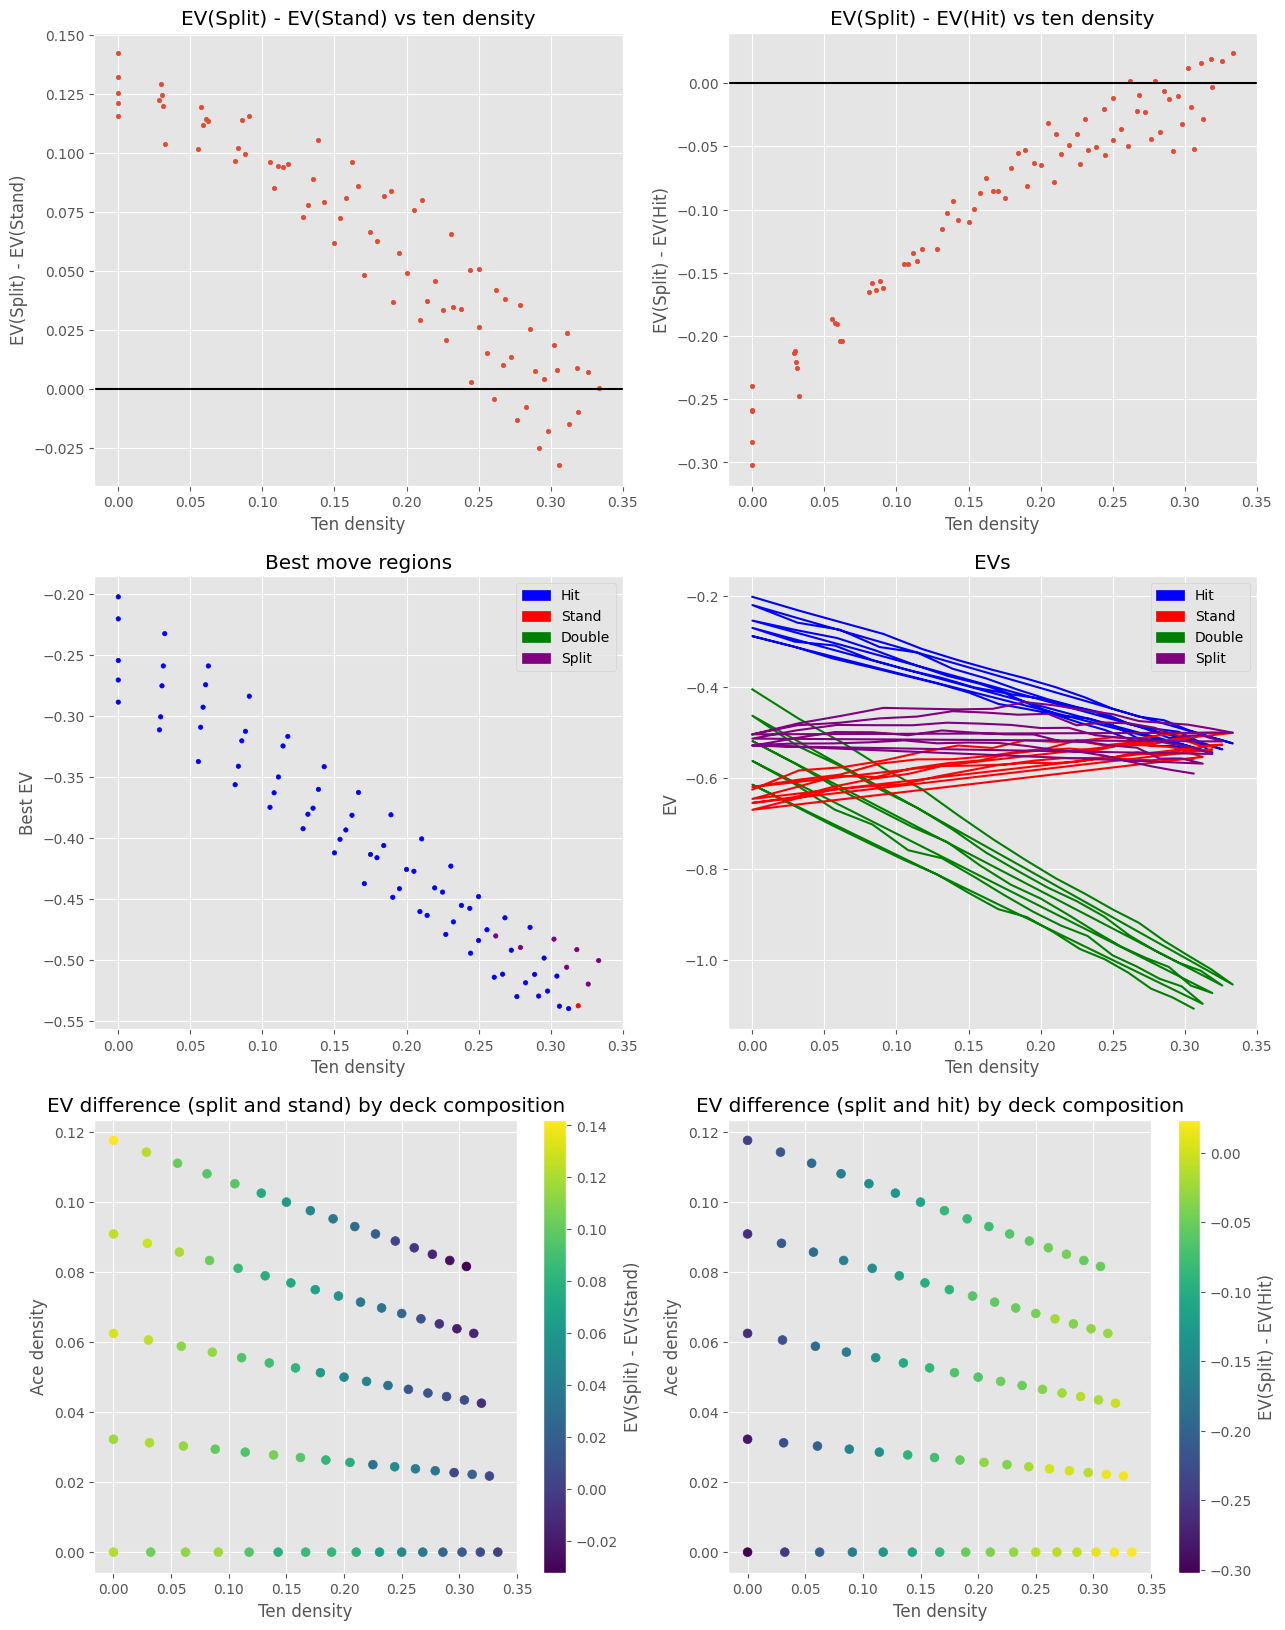

In [11]:
plot_split(datasets, "case_8-8vs10")

### Analysis
This case is a bit ambiguous in terms of strategy. While hitting still being the best move for decks that are depleted of tens, for games with low ace density splitting becomes more and more optimal the more saturated the deck is with tens. The decision confidence, nevertheless, in the perfect game is close to 0, i.e. the choice of the next move has almost no influence on the estimated value of net profit.
## Case: A,A vs 4

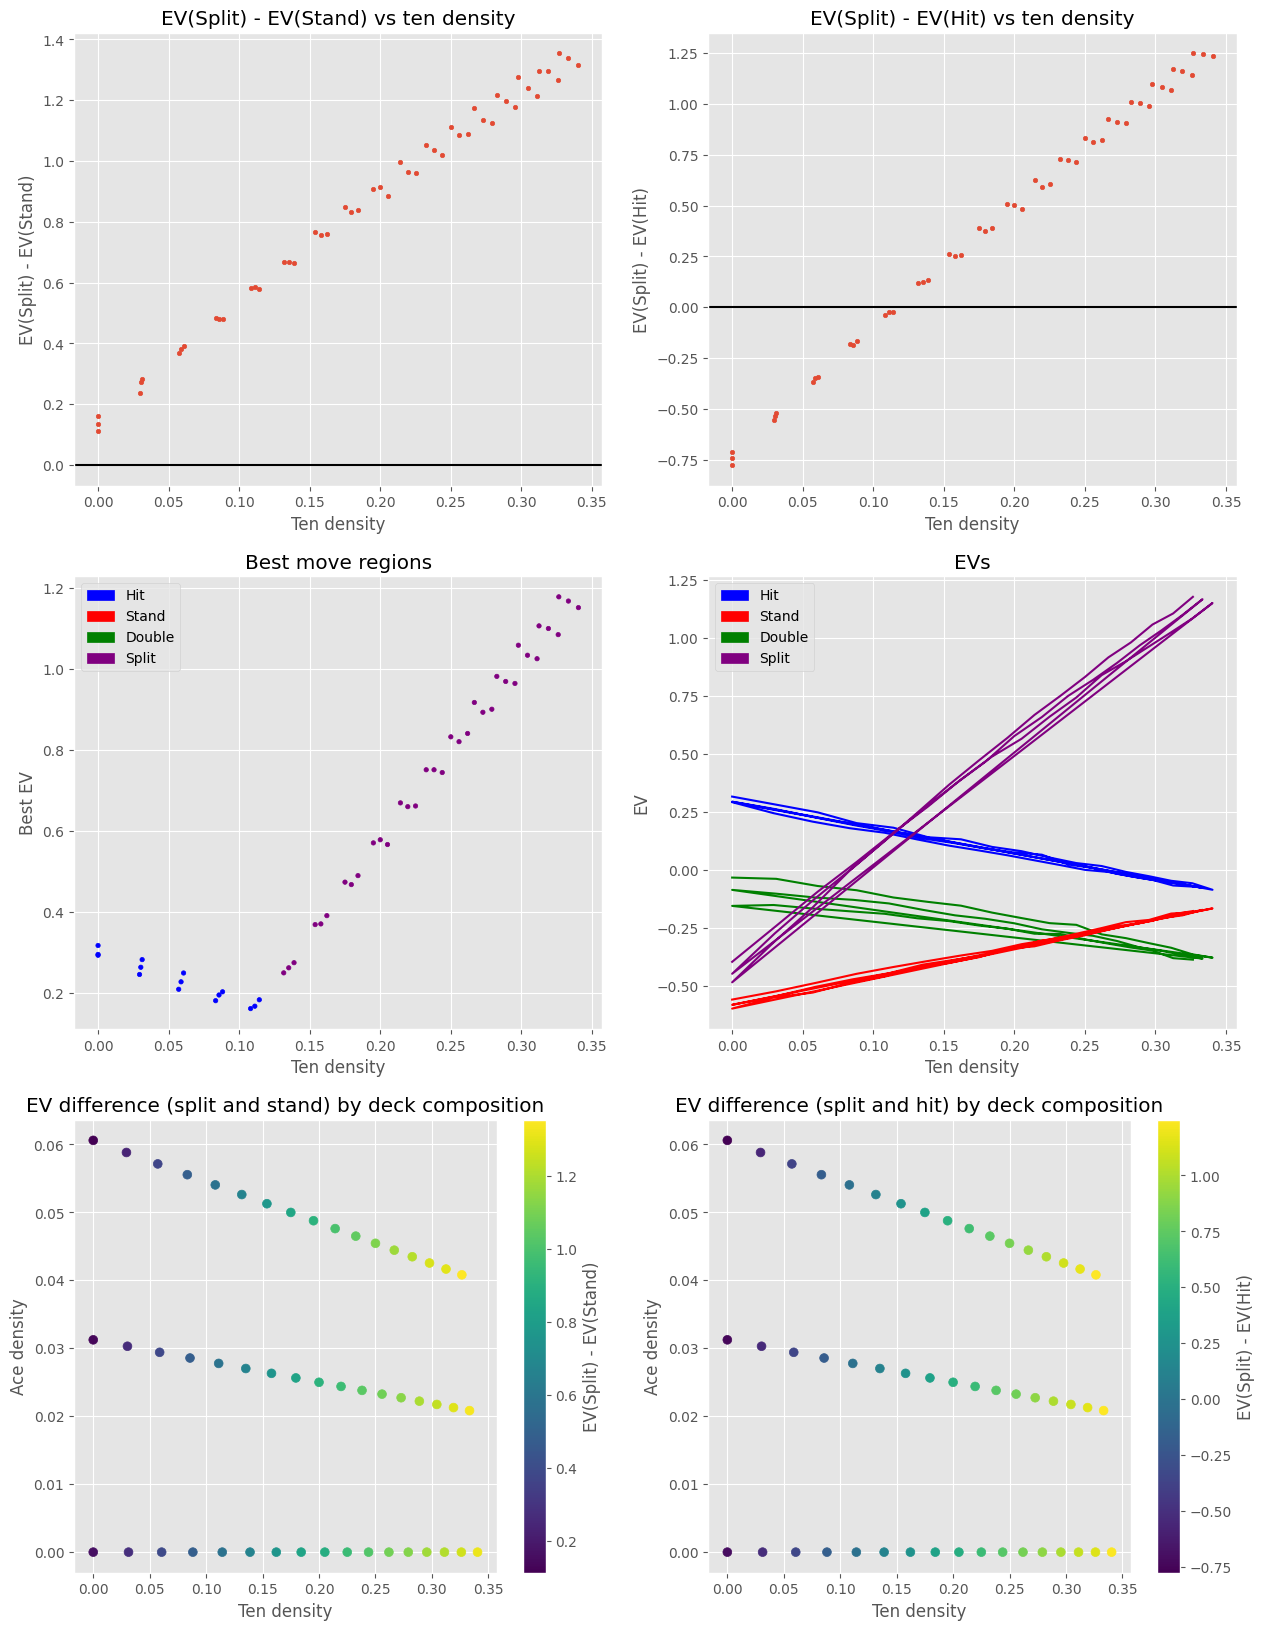

In [12]:
plot_split(datasets, "case_A-Avs4")

### Analysis
While splitting aces against the dealer's 4 is considered the best move, similarly to the previous cases, hitting under a depletion of tens ensures a better estimated value of net profit. Another reason for that is that after the player splits aces, they are only allowed to draw one additional card (unless it's another ace, that they can resplit). With very few tens left in the deck, the probability of getting a 21 significantly decreases, which makes treating the hand as soft 12 and hitting safer and less risky.
***
## Case: 9,9 vs 7

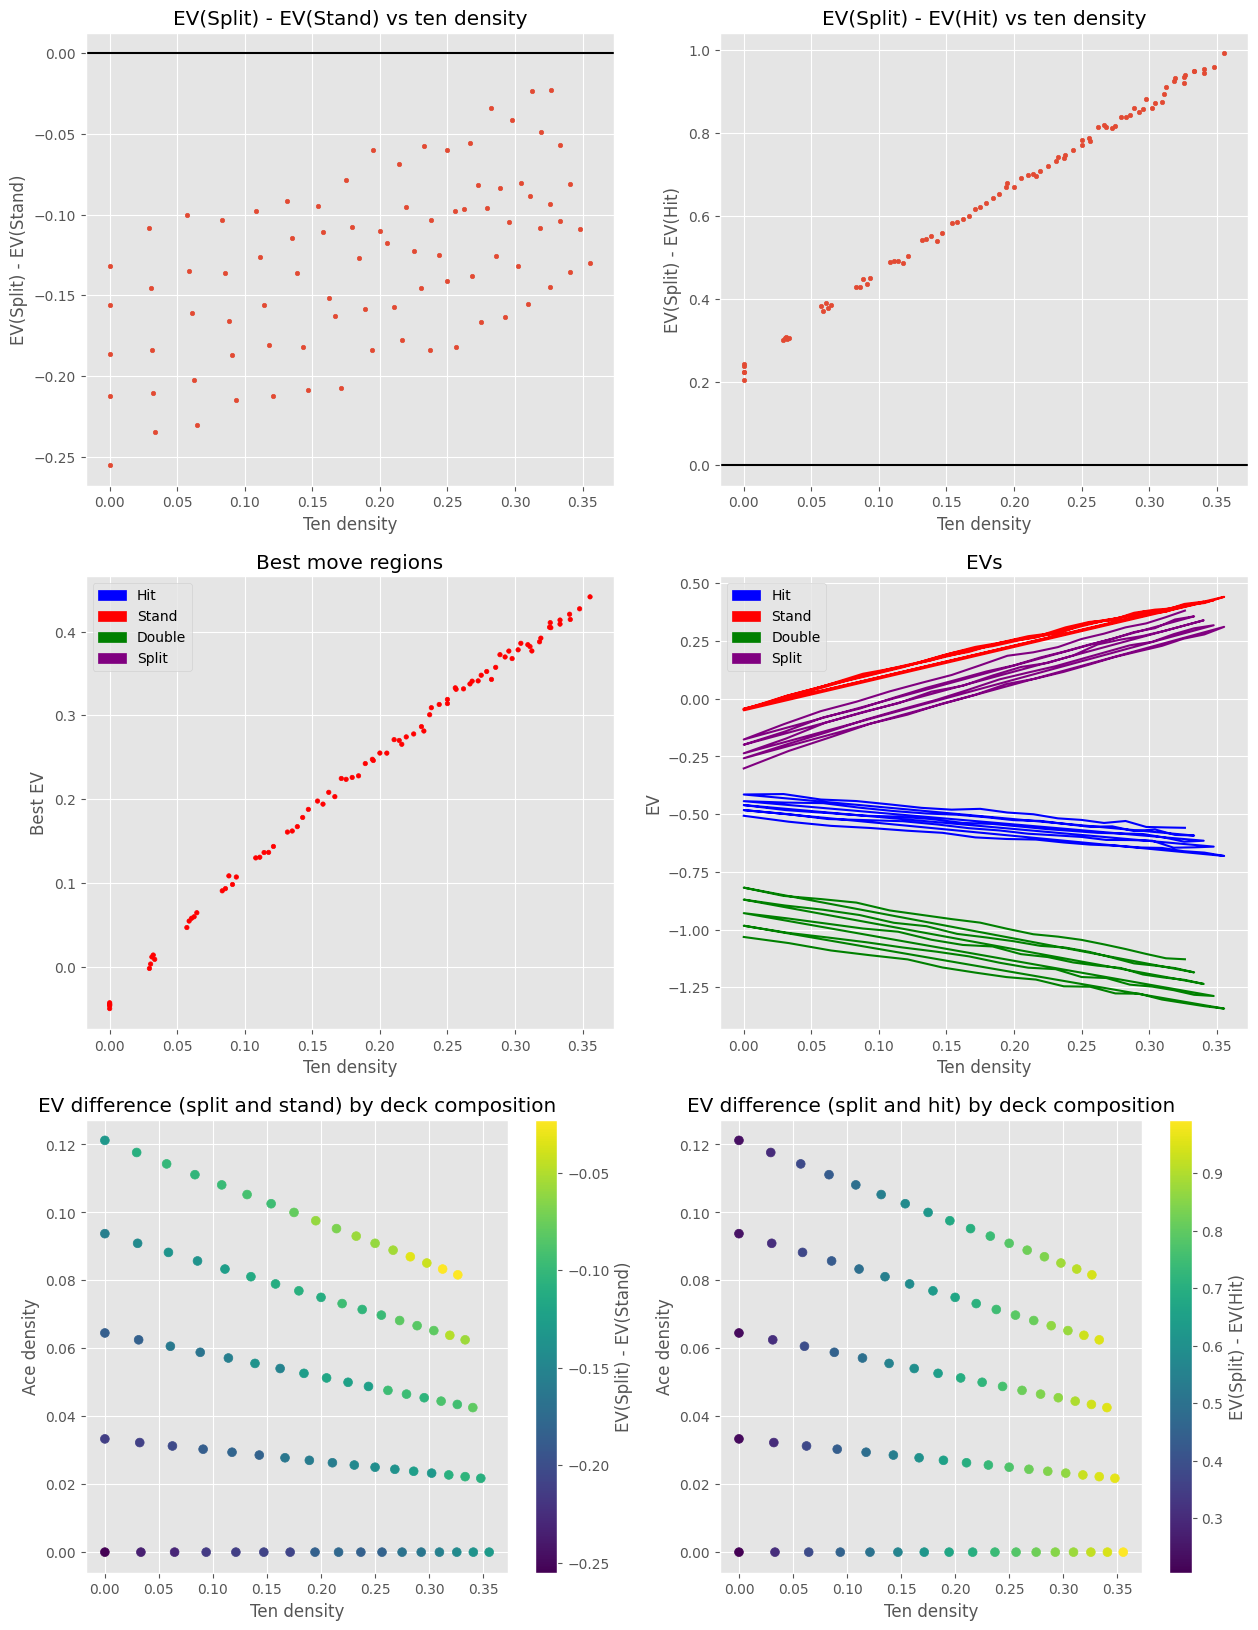

In [13]:
plot_split(datasets, "case_9-9vs7")

### Analysis
The trends in this case differ a lot from the previous ones. Standing is the dominant strategy no matter the ten density. However, the EV of net profit with regard to hitting is expectedly low, as the total of hard 18 is already strong enough against a 7 and, furthermore, extremely prone to busting. The EV of split raises with the ten density but is still lower than EV of standing.